# Semi-Supervised Training (SimCLR + Supervised) 
We start by downloading (loading) the model along with its transformations and tokenizers.

In [3]:
import open_clip
import torch
import json
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import random
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# 1. Load the model, training transforms, and tokenizer
model_name = 'ViT-B-32'
pretrained_weights = 'openai'

model, base_train_transform, val_transform = open_clip.create_model_and_transforms(
    model_name, 
    pretrained=pretrained_weights
)

model = model.to(device)

tokenizer = open_clip.get_tokenizer(model_name)
print("Model and Tokenizer loaded successfully!")


/nobackup/marfr380/clip_venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


/nobackup/marfr380/clip_venv/lib/python3.10/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Model and Tokenizer loaded successfully!


# Dataset
We can start by taking a look at the data we have access to.

According to the project document, we have the following splits:
* Split A (referred to as “train” in the json file; 8734 images) – This will be treated as
the unlabeled dataset for semi-supervised fine-tuning. Only images, no captions,
can be used in this project!
* Split B (referred to as “validation” in the json file; 1094 images) – This will be treated
as the labeled dataset for training (images with captions). It is suggested to further
split this into “real” training and validation sets.
* Split C (referred to as “test” in the json file; 1093 images) – This will be treated as
the labeled dataset for final evaluation (images with captions and class labels).

In [10]:
with open("data/dataset_rsicd.json", "r") as f:
    data = json.load(f)
images = data["images"][0]
print("Images has the following keys:", " | ".join(list(images.keys())))
print("Name of our dataset:", data['dataset'])

# Lets divide the data into their respective splits:
splitA = [i for i in data["images"] if i["split"] == "train"] # (Unlabeled dataset) Not allowed to use sentences
splitB = [i for i in data["images"] if i["split"] == "val"]   # (Labeled dataset) Allowed to use sentences
splitC = [i for i in data["images"] if i["split"] == "test"]  # Actual tess dataset for evaluating performance
print("Splits loaded...")

Images has the following keys: filename | imgid | sentences | split | sentids
Name of our dataset: RSICD
Splits loaded...


There are some more details regarding the sentences in the project descriptions:
* *Note that each image is accompanied by five text descriptions (captions). It is recommended to utilize all of the captions from Split B during training*

So, we can take a look at some random examples of this below.

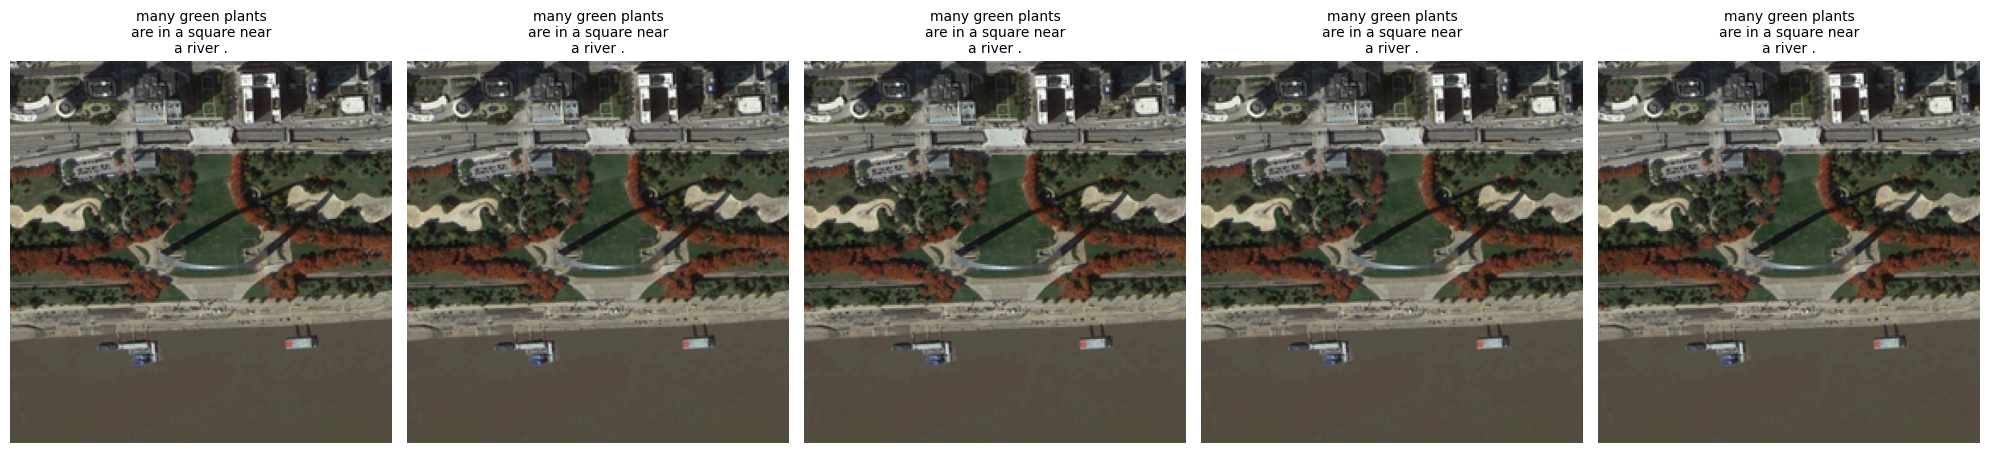

In [5]:
import textwrap
example = splitB[random.randint(0, len(splitB))]
image = Image.open(f"data/RSICD_images/{example['filename']}")
descriptions = [sent['raw'] for sent in example['sentences']]

# Assuming 'image' and 'descriptions' are already defined from your snippet
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, ax in enumerate(axes):
    ax.imshow(image)
    # Wrap text so it doesn't run off the side of the subplot
    wrapped_text = textwrap.fill(descriptions[i], width=20)
    ax.set_title(wrapped_text, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Transformations
**ViT-B-32** only accepts images of size *224x224*. This is part of what the transformations we get when downloading the model `base_train_transform` and `val_transform`, they crop the images in different ways and normalizes the pixels to values that the model saw during training. 
* `base_train_transform` would normaly crop a random patch in the image and scales it down to 224x224, followed by rest of the transformations, it does this so that the training becomes more varied.
* `val_transform` is what is used for real world examples, it does a "center crop" - taking the biggest possible square in the center of the image and then scales it down, followed by the reamining transformations.

For our given RSICD Dataset, it seems that all the given images are already of the size *224x224*, which means the actual transform will only normalize the pixel values.
We can try to visualize it, but the results might look quite bad. (the normalization also puts the pixel values in the negative range, which is not valid in matplotlib)

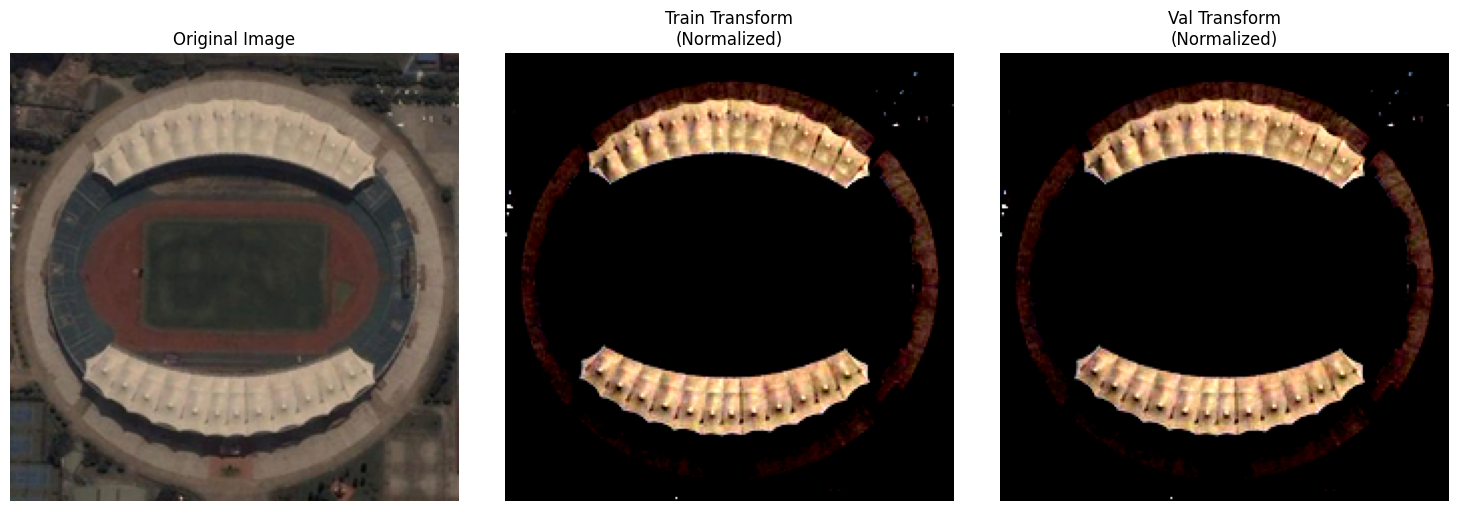

In [6]:
# 1. Get a sample image
example_item = splitB[random.randint(0, len(splitB))] 
raw_img = Image.open(f"data/RSICD_images/{example_item['filename']}").convert('RGB')

# 2. Apply the transforms (these return Tensors)
img_train_tensor = base_train_transform(raw_img)
img_val_tensor = val_transform(raw_img)

# 3. Plotting logic
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original (PIL Image works directly with imshow)
axes[0].imshow(raw_img)
axes[0].set_title("Original Image", fontsize=12)

# Training Transform (Must swap dimensions from CxHxW to HxWxC)
# We use .permute(1, 2, 0) to move the Color channel to the end
axes[1].imshow(img_train_tensor.permute(1, 2, 0))
axes[1].set_title("Train Transform\n(Normalized)", fontsize=12)

# Validation Transform
axes[2].imshow(img_val_tensor.permute(1, 2, 0))
axes[2].set_title("Val Transform\n(Normalized)", fontsize=12)

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

# SimCLR Transformations
Previously we have only looked at rather simple transformations which are typically used when doing **image-text contrastive learning**. 

In that case, we usually only perform mild augmentations—like randomly cropping the image to a valid tensor size. We do this because we want to retain as much original detail as possible. Since the model is learning to align an image with a specific text description, heavily distorting the image could destroy the exact visual information the text is referring to.

On the other hand, when performing unlabeled training with **SimCLR**, our goal is to force the model to learn a rich, robust understanding of images without any text descriptions to guide it. To achieve this, we train the model to map "similar" images close to each other in the embedding space. 

However, if we only optimize for similarity, the model will quickly find a trivial solution: predicting the exact same embedding (e.g., a vector of all `0.0`s) for every single image. This would technically achieve a perfect similarity score, but it destroys any meaningful representation. This failure mode is known as **model collapse**. 

To prevent model collapse, contrastive learning algorithms like SimCLR introduce **negative samples**. The objective becomes dual-purpose: the model must pull similar images close together, while simultaneously pushing dissimilar images as far apart as possible. This push-and-pull dynamic prevents collapse. If the model lazily outputs all zeros, it might get a perfect score for similar images, but it will receive a massive penalty for failing to separate the dissimilar ones.

But how do we know which images are similar and dissimilar in an unlabeled dataset? We use a **self-supervised approach** driven by heavy data augmentation. 

For every image, we apply two completely random series of transformations (like random crops, heavy color distortions, blurring, and flips) to create two distinct "views" of the original image. Because these two views originate from the same image, they act as our **positive pair**. By forcing the model to recognize that a heavily color-jittered crop and a flipped grayscale crop still depict the same semantic content, the model learns to ignore superficial pixel-level noise and extract the core, invariant features of the object.

During training, we apply this process to a full batch of $N$ original images, resulting in $2N$ augmented images. For any given image in this batch, the math works out perfectly:
*   **1** positive example (its differently augmented twin).
*   **$2N - 2$** negative examples (every other augmented image in the batch). 

We can showcase what this will look like with an example:

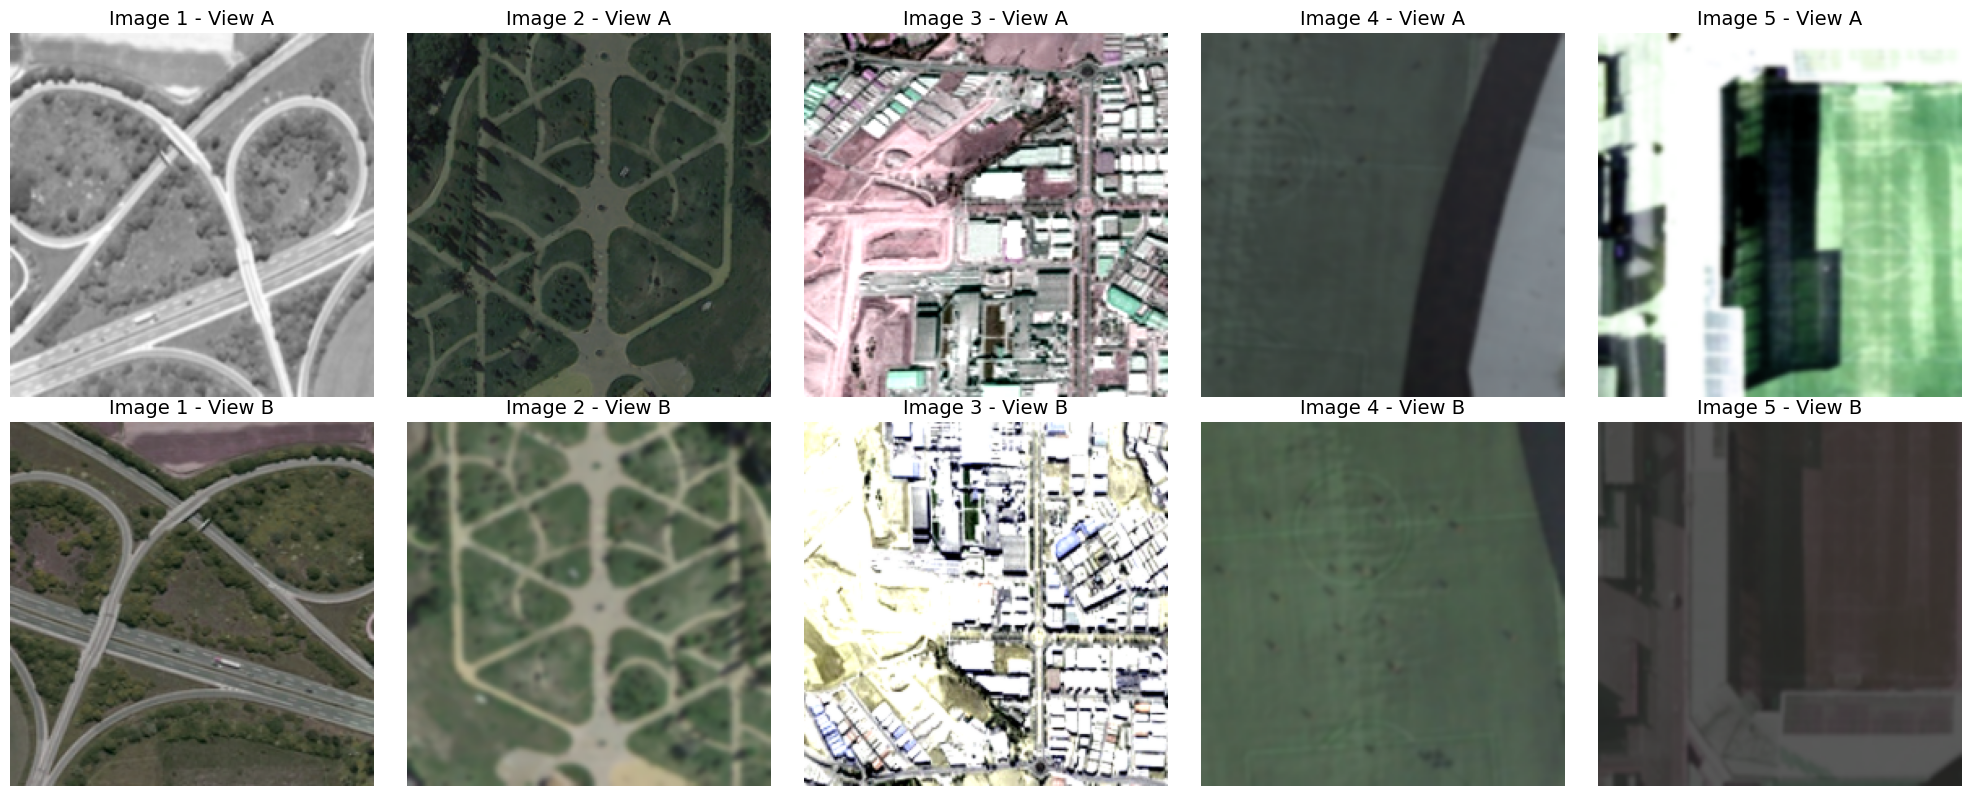

In [7]:
# 1. Define the SimCLR transform WITHOUT normalization
simclr_transform = T.Compose([
    # Spatial: Aggressive Crop and Resize
    T.RandomResizedCrop(224, scale=(0.2, 1.0)), 
    
    # Spatial: Flips & Rotations
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    
    # Visual: Color Distortion
    T.RandomApply([T.ColorJitter(0.8, 0.8, 0.8, 0.2)], p=0.8),
    T.RandomGrayscale(p=0.2),
    
    # Visual: Gaussian Blur (Helps prevent the model from memorizing sharp high-frequency noise)
    T.RandomApply([T.GaussianBlur(kernel_size=23, sigma=(0.1, 2.0))], p=0.5),
    
    # Convert to Tensor
    T.ToTensor(),
])

# Select 5 random images from Split A (the unlabeled data)
random_samples = random.sample(splitA, 5)

# Create a 2x5 grid plot (2 rows, 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, item in enumerate(random_samples):
    # Load the raw image
    img_path = f"data/RSICD_images/{item['filename']}"
    raw_img = Image.open(img_path).convert('RGB')
    
    # Create two completely different augmented views of the SAME image
    view_1 = simclr_transform(raw_img)
    view_2 = simclr_transform(raw_img)
    
    # Top Row: View 1
    # .permute(1, 2, 0) changes shape from [Channels, Height, Width] to [Height, Width, Channels]
    axes[0, i].imshow(view_1.permute(1, 2, 0))
    axes[0, i].set_title(f"Image {i+1} - View A", fontsize=14)
    axes[0, i].axis('off')
    
    # Bottom Row: View 2
    axes[1, i].imshow(view_2.permute(1, 2, 0))
    axes[1, i].set_title(f"Image {i+1} - View B", fontsize=14)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# Creating our Datasets for Training.
Since we are not allowed to do any testing or hyperparameter tuning on Split C, we have to instead use Split B to create our training and test splits.

We can do this by shuffling our data and then splitting it up into two parts of a desired percentage.

In [13]:
# Define split sizes
training_size = 0.9

# Reproducibility
random.seed(42)

# Shuffle our data
random.shuffle(splitB)
splitIdx = int(len(splitB) * training_size) 

splitB_tr = splitB[:splitIdx]
splitB_te = splitB[splitIdx:]

print(f"Original total:    {len(splitB):>5}")
print(f"Training samples:  {len(splitB_tr):>5} ({training_size*100:.0f}%)")
print(f"Validation samples: {len(splitB_te):>5} ({(1-training_size)*100:.0f}%)")

Original total:     1094
Training samples:    984 (90%)
Validation samples:   110 (10%)


# Datasets & DataLoaders
Now that we have our splits ready - we can initialize our Dataset classes.
For every image in splitB, there is actually going to be 5 training examples, because each image has as we saw earlier 5 captions. 
Our Dataset class will take care of creating separate examples for all of them.

As for our Split A, since we do not use any captions, we are going to have exactly as many training examples as we have images. Although since we will create random views of every image as we load our batches, one could argue we have a lot more examples.

In [ ]:
from rsiddataset import RSICDUnlabeledDataset, RSICDLabeledDataset

image_dir = "data/RSICD_images"


# Extract the exact normalization layer from the official CLIP transform
clip_normalize = base_train_transform.transforms[-1] 

simclr_transform = T.Compose([
    T.RandomResizedCrop(224, scale=(0.2, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomApply([T.ColorJitter(0.8, 0.8, 0.8, 0.2)], p=0.8),
    T.RandomGrayscale(p=0.2),
    T.RandomApply([T.GaussianBlur(kernel_size=23, sigma=(0.1, 2.0))], p=0.5),
    
    T.ToTensor(), # Convert to Tensor
    
    clip_normalize # Reuse the normalization from the given transform.
])

training_a = RSICDUnlabeledDataset(splitA, img_dir=image_dir, transform=simclr_transform)

training_b = RSICDLabeledDataset(splitB_tr, img_dir=image_dir, transform=base_train_transform, tokenizer=tokenizer)
test_b     = RSICDLabeledDataset(splitB_te, img_dir=image_dir, transform=base_train_transform, tokenizer=tokenizer)

# Print number of examples in each dataset
print(f"Training A (Unlabeled):  {len(training_a):>6} images")
print(f"Training B (Labeled):    {len(training_b):>6} caption-image pairs")
print(f"Validation B (Labeled):  {len(test_b):>6} caption-image pairs")

Training A (Unlabeled):    8734 images
Training B (Labeled):      4920 caption-image pairs
Validation B (Labeled):     550 caption-image pairs


In [ ]:
BATCH_SIZE = 64

loader_A = DataLoader(training_a, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
loader_B = DataLoader(training_b, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

# Validation doesn't need drop_last or shuffle
val_loader_B = DataLoader(test_b, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)